# Notebook 17: TCGA-COAD Cancer Subtyping

## Pathway-Based Molecular Subtyping Applied to Colorectal Adenocarcinoma

**Dataset:** [TCGA-COAD](https://www.cancer.gov/ccg/research/genome-sequencing/tcga/studied-cancers/colon-adenocarcinoma) — The Cancer Genome Atlas Colon Adenocarcinoma  
**Data source:** [NCI GDC REST API](https://gdc.cancer.gov/developers/gdc-application-programming-interface-gdc-api) — STAR Counts (TPM), log2(TPM+1)
**Pathways:** MSigDB Hallmark gene sets (50 gene sets, cancer biology)  
**Framework:** [pathway-subtyping](https://pypi.org/project/pathway-subtyping/) v0.3.1  
**Author:** Rohit Chauhan ([ORCID: 0009-0003-9895-4629](https://orcid.org/0009-0003-9895-4629))

---

## Purpose

This notebook demonstrates that the pathway-based molecular subtyping framework is **disease-agnostic** by applying it to cancer — specifically colorectal adenocarcinoma (COAD). The framework was originally developed for psychiatric disorders (autism, schizophrenia); here we test whether it can independently recover clinically meaningful substructure in an entirely different disease.

**Scientific context:** COAD is highly heterogeneous with 4 established Consensus Molecular Subtypes (CMS1–4; Guinney et al. 2015, *Nature Medicine*). CMS1 is MSI-high with immune infiltration; CMS2 is CIN-high with WNT/MYC activation; CMS3 is KRAS-mutated; CMS4 has mesenchymal/stromal features. Our analysis is run **blind to CMS labels** — we then compare at the end.

**Clinical relevance:** Results shared with:
- **Deepali Kundnani** (MD Anderson) — GI cancer computational biology
- **Faraz Bishehsari** (UTHealth Houston) — GI cancer research

## What this notebook does

1. Downloads TCGA-COAD RNA-seq STAR count data (~460 primary tumor samples) via NCI GDC REST API
2. Downloads MSigDB Hallmark gene sets (50 cancer-relevant pathways)
3. Scores each tumor sample on all 50 Hallmark pathways using ssGSEA
4. Selects optimal number of subtypes via BIC (blinded to CMS labels)
5. Discovers molecular subtypes via GMM clustering in pathway space
6. Validates subtypes through 3 statistical validation gates
7. Characterizes subtypes (enriched pathways, top genes)
8. Benchmarks against alternative methods (NMF, PCA+K-means, gene K-means)
9. **Compares our subtypes to CMS1-4 and MSI status** (external validation)
10. Exports results to `research-results/tcga/`

**Runtime:** ~15–25 minutes on Colab Pro (dominated by ssGSEA scoring + validation gates)

[![Open In Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/git/https%3A%2F%2Fcodeberg.org%2Fpathways%2Fpathway-subtyping-framework/main?labpath=examples%2Fnotebooks%2F17_tcga_cancer_validation.ipynb)

## 1. Setup & Installation

In [1]:
# Install framework and dependencies
!pip install -q 'pathway-subtyping[viz]==0.3.1' requests

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import adjusted_rand_score
from scipy.stats import chi2_contingency

from pathway_subtyping import (
    score_pathways_from_expression,
    ExpressionScoringMethod,
    run_clustering,
    ClusteringAlgorithm,
    select_n_clusters,
    ValidationGates,
    characterize_subtypes,
    generate_subtype_heatmap,
    generate_gene_heatmap,
    export_characterization,
    run_benchmark_comparison,
    compute_dim_reduction,
    DimReductionMethod,
)

import pathway_subtyping
print(f'pathway-subtyping v{pathway_subtyping.__version__}')

# Reproducibility
SEED = 42
np.random.seed(SEED)
K_RANGE = list(range(2, 8))

# Directories
OUTPUT_DIR = './research-results/tcga'
DATA_DIR = './data/tcga'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print(f'Data directory:   {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')
print('Setup complete.')


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


pathway-subtyping v0.3.1
Data directory:   ./data/tcga
Output directory: ./research-results/tcga
Setup complete.


## 2. TCGA-COAD Data Download (NCI GDC REST API)

We download TCGA-COAD RNA-seq data from the **NCI Genomic Data Commons (GDC) REST API** — no authentication required for open-access TCGA data.

| Data | Source | Description |
|------|--------|-------------|
| **Expression** | GDC Files API | STAR-Counts workflow, TPM values, ~460 primary tumors |
| **Clinical** | GDC Cases API | Tumor stage, MSI status, vital status, demographics |

**GDC API base:** `https://api.gdc.cancer.gov/`

> [!NOTE]
> Bulk expression download fetches ~460 STAR count files as a single tar.gz archive
> (~600–800 MB, ~5–20 min depending on connection speed). Streamed and cached to
> `./data/tcga/` — subsequent runs use the cache and skip the download entirely.

In [2]:
import requests
import tarfile

GDC_FILES_URL = 'https://api.gdc.cancer.gov/files'
GDC_DATA_URL  = 'https://api.gdc.cancer.gov/data'
GDC_CASES_URL = 'https://api.gdc.cancer.gov/cases'


def download_file(urls, dest_path, desc='file', retries=3):
    # Download from one of several URLs with caching and retry logic.
    # Kept for Hallmark GMT download in cell below.
    if os.path.exists(dest_path) and os.path.getsize(dest_path) > 0:
        size_mb = os.path.getsize(dest_path) / (1024**2)
        print(f'[Cache] {desc} ({size_mb:.1f} MB): {dest_path}')
        return dest_path
    urls = [urls] if isinstance(urls, str) else urls
    last_error = None
    for url in urls:
        for attempt in range(1, retries + 1):
            try:
                print(f'[Download] Attempt {attempt}/{retries}: {url[:80]}...')
                r = requests.get(url, stream=True, timeout=120)
                r.raise_for_status()
                with open(dest_path, 'wb') as f:
                    downloaded = 0
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        f.write(chunk)
                        downloaded += len(chunk)
                        print(f'\r  {downloaded / (1024**2):.0f} MB downloaded...', end='', flush=True)
                print()
                size_mb = os.path.getsize(dest_path) / (1024**2)
                print(f'[OK] {desc} saved ({size_mb:.1f} MB)')
                return dest_path
            except Exception as e:
                last_error = e
                print(f'\n[Warn] Attempt {attempt} failed: {e}')
                if os.path.exists(dest_path):
                    os.remove(dest_path)
                if attempt < retries:
                    time.sleep(2 ** (attempt - 1))
        print(f'[Warn] All {retries} attempts failed for: {url[:60]}')
    raise RuntimeError(f'Failed to download {desc}.\nLast error: {last_error}')


def query_gdc_files(project_id, sample_type='Primary Tumor', max_files=600):
    # Query GDC files API for STAR-Counts files; return list of {file_id, sample_id}.
    filters = {
        'op': 'and',
        'content': [
            {'op': 'in', 'content': {'field': 'cases.project.project_id', 'value': [project_id]}},
            {'op': 'in', 'content': {'field': 'data_category', 'value': ['Transcriptome Profiling']}},
            {'op': 'in', 'content': {'field': 'data_type', 'value': ['Gene Expression Quantification']}},
            {'op': 'in', 'content': {'field': 'experimental_strategy', 'value': ['RNA-Seq']}},
            {'op': 'in', 'content': {'field': 'cases.samples.sample_type', 'value': [sample_type]}},
        ],
    }
    params = {
        'filters': json.dumps(filters),
        'fields': 'file_id,file_name,cases.submitter_id',
        'format': 'JSON',
        'size': str(max_files),
    }
    r = requests.get(GDC_FILES_URL, params=params, timeout=60)
    r.raise_for_status()
    hits = r.json()['data']['hits']
    manifest, seen = [], set()
    for hit in hits:
        fid = hit['file_id']
        cases = hit.get('cases', [{}])
        barcode = cases[0].get('submitter_id', fid) if cases else fid
        if barcode not in seen:
            manifest.append({'file_id': fid, 'sample_id': barcode})
            seen.add(barcode)
    return manifest


def download_gdc_bulk(file_ids, cache_path):
    # POST file IDs to GDC data endpoint; stream tar.gz to cache_path.
    tmp_path = cache_path + '.tmp'
    if os.path.exists(cache_path) and os.path.getsize(cache_path) > 10_000:
        size_mb = os.path.getsize(cache_path) / (1024**2)
        print(f'[Cache] GDC archive ({size_mb:.0f} MB): {cache_path}')
        return
    if os.path.exists(tmp_path):
        os.remove(tmp_path)
    print(f'[GDC] Requesting {len(file_ids)} files from GDC (streaming ~600-800 MB)...')
    r = requests.post(GDC_DATA_URL, json={'ids': file_ids}, stream=True, timeout=3600)
    r.raise_for_status()
    downloaded, last_report = 0, 0
    chunk_size = 4 * 1024 * 1024
    with open(tmp_path, 'wb') as fout:
        for chunk in r.iter_content(chunk_size=chunk_size):
            fout.write(chunk)
            downloaded += len(chunk)
            if downloaded - last_report >= 50 * 1024 * 1024:
                print(f'  {downloaded / (1024**2):.0f} MB downloaded...')
                last_report = downloaded
    os.rename(tmp_path, cache_path)
    print(f'[OK] {downloaded / (1024**2):.0f} MB saved to {cache_path}')


def parse_star_tsv(fileobj):
    # Parse STAR augmented count TSV; return pd.Series(gene_name -> tpm_unstranded).
    df = pd.read_csv(fileobj, sep='\t', comment='#', low_memory=False)
    # Drop N_unmapped / N_multimapping / N_noFeature / N_ambiguous summary rows
    df = df[df['gene_name'].notna() & ~df['gene_name'].astype(str).str.startswith('N_')]
    df = df[df['tpm_unstranded'].notna()]
    df = df.drop_duplicates('gene_name')
    return df.set_index('gene_name')['tpm_unstranded']


def query_gdc_clinical(project_id, max_cases=600):
    # Query GDC cases API; return DataFrame indexed by case submitter_id.
    params = {
        'filters': json.dumps({
            'op': 'in',
            'content': {'field': 'project.project_id', 'value': [project_id]},
        }),
        'fields': ','.join([
            'submitter_id',
            'diagnoses.tumor_stage',
            'diagnoses.vital_status',
            'diagnoses.days_to_death',
            'diagnoses.days_to_last_follow_up',
            'diagnoses.microsatellite_instability_abnormal',
            'demographic.gender',
            'demographic.race',
            'demographic.age_at_index',
        ]),
        'format': 'JSON',
        'size': str(max_cases),
    }
    r = requests.get(GDC_CASES_URL, params=params, timeout=60)
    r.raise_for_status()
    hits = r.json()['data']['hits']
    rows = []
    for hit in hits:
        row = {'sample_id': hit.get('submitter_id', '')}
        diag = (hit.get('diagnoses') or [{}])[0]
        row['tumor_stage']            = diag.get('tumor_stage')
        row['vital_status']           = diag.get('vital_status')
        row['days_to_death']          = diag.get('days_to_death')
        row['days_to_last_follow_up'] = diag.get('days_to_last_follow_up')
        msi = diag.get('microsatellite_instability_abnormal')
        row['msi_status'] = 'MSI-H' if msi is True else ('MSS' if msi is False else None)
        demo = hit.get('demographic') or {}
        row['gender']       = demo.get('gender')
        row['race']         = demo.get('race')
        row['age_at_index'] = demo.get('age_at_index')
        rows.append(row)
    return pd.DataFrame(rows).set_index('sample_id')


print('GDC API and download helpers defined.')

GDC API and download helpers defined.


In [3]:
# ── Query file manifest ──────────────────────────────────────────────────────
print('[GDC] Querying TCGA-COAD STAR-Counts file manifest...')
manifest = query_gdc_files('TCGA-COAD', sample_type='Primary Tumor', max_files=600)
print(f'      {len(manifest)} primary tumor files found')

file_ids      = [m['file_id']   for m in manifest]
id_to_barcode = {m['file_id']: m['sample_id'] for m in manifest}

# ── Bulk download (cached to disk) ───────────────────────────────────────────
EXPR_TAR_PATH = os.path.join(DATA_DIR, 'TCGA-COAD-star-counts.tar.gz')
download_gdc_bulk(file_ids, EXPR_TAR_PATH)

# ── Parse tar.gz → expression matrix ─────────────────────────────────────────
print('\n[Parse] Extracting STAR-Counts TSVs from archive...')
sample_series = {}
with tarfile.open(EXPR_TAR_PATH, mode='r:*') as tar:
    members = [m for m in tar.getmembers()
               if m.name.endswith('.tsv') and 'MANIFEST' not in m.name.upper()]
    print(f'  {len(members)} TSV files in archive')
    for i, member in enumerate(members):
        if (i + 1) % 50 == 0 or (i + 1) == len(members):
            print(f'  Parsed {i + 1}/{len(members)}...', end='\r')
        fid = member.name.split('/')[0]
        barcode = id_to_barcode.get(fid, fid)
        if barcode in sample_series:
            continue  # one sample per patient
        fobj = tar.extractfile(member)
        if fobj:
            try:
                sample_series[barcode] = parse_star_tsv(fobj)
            except Exception as e:
                print(f'\n  [Warn] Parse failed for {member.name[:60]}: {e}')

print(f'\n[OK] Parsed {len(sample_series)} samples')

# ── Build matrix (samples x genes) ───────────────────────────────────────────
gene_expression = pd.DataFrame(sample_series).T
gene_expression.index.name = 'sample_id'
print(f'Expression matrix: {gene_expression.shape}  (samples x genes)')

# ── Normalize: log2(TPM + 1) ─────────────────────────────────────────────────
print('[Transform] log2(TPM + 1)')
gene_expression = np.log2(gene_expression + 1)

# ── QC: remove zero-variance genes ───────────────────────────────────────────
var = gene_expression.var()
n_before = gene_expression.shape[1]
gene_expression = gene_expression.loc[:, var > 0]
print(f'Genes removed (zero variance): {n_before - gene_expression.shape[1]:,}')

n_samples, n_genes = gene_expression.shape
print(f'\nFinal expression matrix: {n_samples} samples x {n_genes:,} genes')

[GDC] Querying TCGA-COAD STAR-Counts file manifest...


      458 primary tumor files found
[Cache] GDC archive (432 MB): ./data/tcga/TCGA-COAD-star-counts.tar.gz

[Parse] Extracting STAR-Counts TSVs from archive...


  458 TSV files in archive


  Parsed 458/458...
[OK] Parsed 458 samples


Expression matrix: (458, 59427)  (samples x genes)
[Transform] log2(TPM + 1)


Genes removed (zero variance): 3,566

Final expression matrix: 458 samples x 55,861 genes


In [4]:
# ── Clinical: GDC cases API ──────────────────────────────────────────────────
print('[GDC] Querying TCGA-COAD clinical metadata...')
clinical = query_gdc_clinical('TCGA-COAD', max_cases=600)
print(f'      {len(clinical)} cases returned')

# ── Align expression <-> clinical ────────────────────────────────────────────
common = gene_expression.index.intersection(clinical.index)
print(f'\nExpression samples: {len(gene_expression)}')
print(f'Clinical cases:     {len(clinical)}')
print(f'Matched:            {len(common)}')

if len(common) < 50:
    # Fallback: match on 12-char patient barcode prefix
    print('[Warn] Low overlap — trying 12-char barcode matching...')
    expr_12 = gene_expression.copy()
    expr_12.index = expr_12.index.str[:12]
    clin_12 = clinical.copy()
    clin_12.index = clin_12.index.str[:12]
    common = expr_12.index.intersection(clin_12.index)
    print(f'  After 12-char truncation: {len(common)} matched')
    gene_expression = expr_12.loc[common]
    clinical = clin_12.loc[common].copy()
else:
    gene_expression = gene_expression.loc[common]
    clinical = clinical.loc[common].copy()

# ── Identify key clinical columns (used in cells below) ──────────────────────
cms_cols   = [c for c in clinical.columns if 'cms' in c.lower()]
msi_cols   = [c for c in clinical.columns if 'msi' in c.lower()]
stage_cols = [c for c in clinical.columns if 'stage' in c.lower()
              and ('path' in c.lower() or 'tumor' in c.lower() or 'clinical' in c.lower())]
kras_cols  = [c for c in clinical.columns if 'kras' in c.lower()]
braf_cols  = [c for c in clinical.columns if 'braf' in c.lower()]

print('\n--- Clinical columns detected ---')
for label, cols in [('CMS', cms_cols), ('MSI', msi_cols), ('Stage', stage_cols),
                    ('KRAS', kras_cols), ('BRAF', braf_cols)]:
    if cols:
        print(f'  {label}: {cols[:3]}')
    else:
        print(f'  {label}: [not found]')

if not cms_cols:
    print('\n[Note] CMS1-4 labels not available via GDC API (published in Guinney 2015).')
    print('       CMS comparison (Section 11) will be skipped.')
if msi_cols:
    msi_preview = clinical[msi_cols[0]].value_counts()
    print(f'\nMSI status ({msi_cols[0]}):')
    print(msi_preview.to_string())

[GDC] Querying TCGA-COAD clinical metadata...


      461 cases returned

Expression samples: 458
Clinical cases:     461
Matched:            458

--- Clinical columns detected ---
  CMS: [not found]
  MSI: ['msi_status']
  Stage: ['tumor_stage']
  KRAS: [not found]
  BRAF: [not found]

[Note] CMS1-4 labels not available via GDC API (published in Guinney 2015).
       CMS comparison (Section 11) will be skipped.

MSI status (msi_status):
Series([], )


In [5]:
print('=== TCGA-COAD Sample Overview ===')
print(f'Tumor samples: {len(gene_expression)}')
print(f'Genes:         {gene_expression.shape[1]:,}')
print(f'Clinical vars: {clinical.shape[1]}')
print()

# MSI status
if msi_cols:
    msi_col = msi_cols[0]
    print(f'MSI Status ({msi_col}):')
    print(clinical[msi_col].value_counts().to_string())
    print()

# Tumor stage (pick first stage-related column)
stage_col = None
if stage_cols:
    stage_col = stage_cols[0]
elif 'tumor_stage' in clinical.columns:
    stage_col = 'tumor_stage'
elif 'pathologic_stage' in clinical.columns:
    stage_col = 'pathologic_stage'

if stage_col:
    print(f'Tumor Stage ({stage_col}):')
    print(clinical[stage_col].value_counts().sort_index().to_string())
    print()

# CMS subtypes
if cms_cols:
    cms_col_check = cms_cols[0]
    valid_cms = clinical[cms_col_check].notna() & (clinical[cms_col_check].astype(str) != 'nan') & (clinical[cms_col_check].astype(str) != 'NA')
    print(f'CMS Subtypes ({cms_col_check}) — {valid_cms.sum()} labeled samples:')
    print(clinical.loc[valid_cms, cms_col_check].value_counts().to_string())
    print()

# KRAS
if kras_cols:
    print(f'KRAS Status ({kras_cols[0]}):')
    print(clinical[kras_cols[0]].value_counts().to_string())
    print()

=== TCGA-COAD Sample Overview ===
Tumor samples: 458
Genes:         55,861
Clinical vars: 8

MSI Status (msi_status):
Series([], )

Tumor Stage (tumor_stage):
Series([], )



## 3. Pathway Loading — Cancer Hallmarks (MSigDB)

We use the **Hallmark gene sets** from the Molecular Signatures Database (MSigDB, Broad Institute) — 50 curated gene sets representing well-defined biological states relevant to cancer.

**Why Hallmarks for colorectal cancer?**
- Direct coverage of key CRC biology: WNT, MYC, TGF-β, hypoxia, EMT, immune checkpoints, apoptosis, cell cycle
- High signal-to-noise: curated to minimize within-set redundancy
- Standard reference for cancer pathway analysis
- Gene symbols match TCGA data directly

**Reference:** Liberzon A et al. (2015) *Cell Systems* 1(6):417–425. DOI: 10.1016/j.cels.2015.12.004

In [6]:
HALLMARKS_URLS = [
    'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2023.2.Hs/h.all.v2023.2.Hs.symbols.gmt',
    'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2022.1.Hs/h.all.v2022.1.Hs.symbols.gmt',
    'https://data.broadinstitute.org/gsea-msigdb/msigdb/release/7.5.1/h.all.v7.5.1.symbols.gmt',
]
HALLMARKS_PATH = os.path.join(DATA_DIR, 'h.hallmarks.gmt')

try:
    download_file(HALLMARKS_URLS, HALLMARKS_PATH, 'MSigDB Hallmark gene sets')
except RuntimeError as e:
    print(f'[Error] {e}')
    print('[Help] Manually download Hallmark gene sets:')
    print('  1. Go to https://www.gsea-msigdb.org/gsea/msigdb/human/collections.jsp')
    print('  2. Download "H: hallmark gene sets" in .gmt format (gene symbols)')
    print(f'  3. Save to: {HALLMARKS_PATH}')
    raise

print('[OK] Hallmark gene sets downloaded.')

[Cache] MSigDB Hallmark gene sets (0.0 MB): ./data/tcga/h.hallmarks.gmt
[OK] Hallmark gene sets downloaded.


In [7]:
def parse_gmt(path):
    """Parse GMT file into {pathway_name: [gene1, gene2, ...]}."""
    pathways = {}
    with open(path) as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 3:
                continue
            name = parts[0]
            genes = [g.strip() for g in parts[2:] if g.strip()]
            pathways[name] = genes
    return pathways


def clean_name(n):
    """Convert HALLMARK_WNT_BETA_CATENIN_SIGNALING → Wnt Beta Catenin Signaling."""
    return n.replace('HALLMARK_', '').replace('_', ' ').title()


pathways = parse_gmt(HALLMARKS_PATH)
print(f'Loaded {len(pathways)} Hallmark gene sets')

# Coverage statistics
all_gmt_genes = set(g for genes in pathways.values() for g in genes)
expr_genes_set = set(gene_expression.columns)
coverage = len(all_gmt_genes & expr_genes_set) / len(all_gmt_genes) * 100

print(f'Total GMT genes:     {len(all_gmt_genes):,}')
print(f'Genes in expression: {len(expr_genes_set):,}')
print(f'GMT gene coverage:   {coverage:.1f}%')

sizes = [len(v) for v in pathways.values()]
print(f'\nPathway sizes: min={min(sizes)}, median={int(np.median(sizes))}, max={max(sizes)}')

# Per-pathway coverage table
cov_rows = []
for name, genes in pathways.items():
    in_expr = len(set(genes) & expr_genes_set)
    cov_rows.append({
        'pathway': clean_name(name),
        'total_genes': len(genes),
        'in_expression': in_expr,
        'coverage_pct': round(in_expr / len(genes) * 100, 1)
    })
cov_df = pd.DataFrame(cov_rows).sort_values('total_genes', ascending=False)

print(f'\nTop 15 pathways by gene count:')
print(cov_df.head(15).to_string(index=False))

Loaded 50 Hallmark gene sets
Total GMT genes:     4,384
Genes in expression: 55,861
GMT gene coverage:   99.6%

Pathway sizes: min=32, median=180, max=200

Top 15 pathways by gene count:
                  pathway  total_genes  in_expression  coverage_pct
             Adipogenesis          200            200         100.0
           G2M Checkpoint          200            200         100.0
  Tnfa Signaling Via Nfkb          200            199          99.5
              P53 Pathway          200            199          99.5
Oxidative Phosphorylation          200            200         100.0
               Myogenesis          200            198          99.0
           Myc Targets V1          200            199          99.5
         Mtorc1 Signaling          200            199          99.5
        Kras Signaling Up          200            200         100.0
        Kras Signaling Dn          200            200         100.0
Interferon Gamma Response          200            199          99

## 4. Pathway Scoring — ssGSEA

Single-Sample Gene Set Enrichment Analysis (ssGSEA) computes a per-sample, per-pathway enrichment score by:
1. Ranking all genes by expression in each sample
2. Computing a running enrichment statistic for each Hallmark gene set
3. Returning a Z-normalized score across all samples

This produces a **samples × 50 pathways** score matrix that captures pathway-level activity variation across the TCGA-COAD cohort.

In [8]:
print(f'Scoring {len(pathways)} pathways across {len(gene_expression)} samples...')
print('Method: ssGSEA (expected runtime: 5-15 minutes)\n')

scoring_result = score_pathways_from_expression(
    gene_expression=gene_expression,
    pathways=pathways,
    method=ExpressionScoringMethod.SSGSEA,
    min_genes_per_pathway=2,
    seed=SEED,
    show_progress=True,
)

pathway_scores = scoring_result.pathway_scores

print(f'\nPathway score matrix: {pathway_scores.shape}  (samples x pathways)')
print(f'Pathways scored:  {scoring_result.n_pathways_scored}')
print(f'Pathways skipped: {scoring_result.n_pathways_skipped}')
if scoring_result.skipped_pathways:
    print(f'Skipped: {scoring_result.skipped_pathways[:5]}')
print(f'\nScore stats: mean={pathway_scores.values.mean():.4f}, '
      f'std={pathway_scores.values.std():.4f}, '
      f'range=[{pathway_scores.values.min():.3f}, {pathway_scores.values.max():.3f}]')

Scoring 50 pathways across 458 samples...
Method: ssGSEA (expected runtime: 5-15 minutes)



ssGSEA:   0%|          | 0/50 [00:00<?, ?it/s]

ssGSEA:   2%|▏         | 1/50 [00:01<00:54,  1.11s/it]

ssGSEA:   4%|▍         | 2/50 [00:02<00:53,  1.10s/it]

ssGSEA:   6%|▌         | 3/50 [00:03<00:51,  1.09s/it]

...

ssGSEA:  96%|█████████▌| 48/50 [00:52<00:02,  1.10s/it]

ssGSEA:  98%|█████████▊| 49/50 [00:53<00:01,  1.10s/it]

ssGSEA: 100%|██████████| 50/50 [00:54<00:00,  1.10s/it]

ssGSEA: 100%|██████████| 50/50 [00:54<00:00,  1.10s/it]


Pathway score matrix: (458, 50)  (samples x pathways)
Pathways scored:  50
Pathways skipped: 0

Score stats: mean=-0.0000, std=0.9989, range=[-9.737, 3.615]


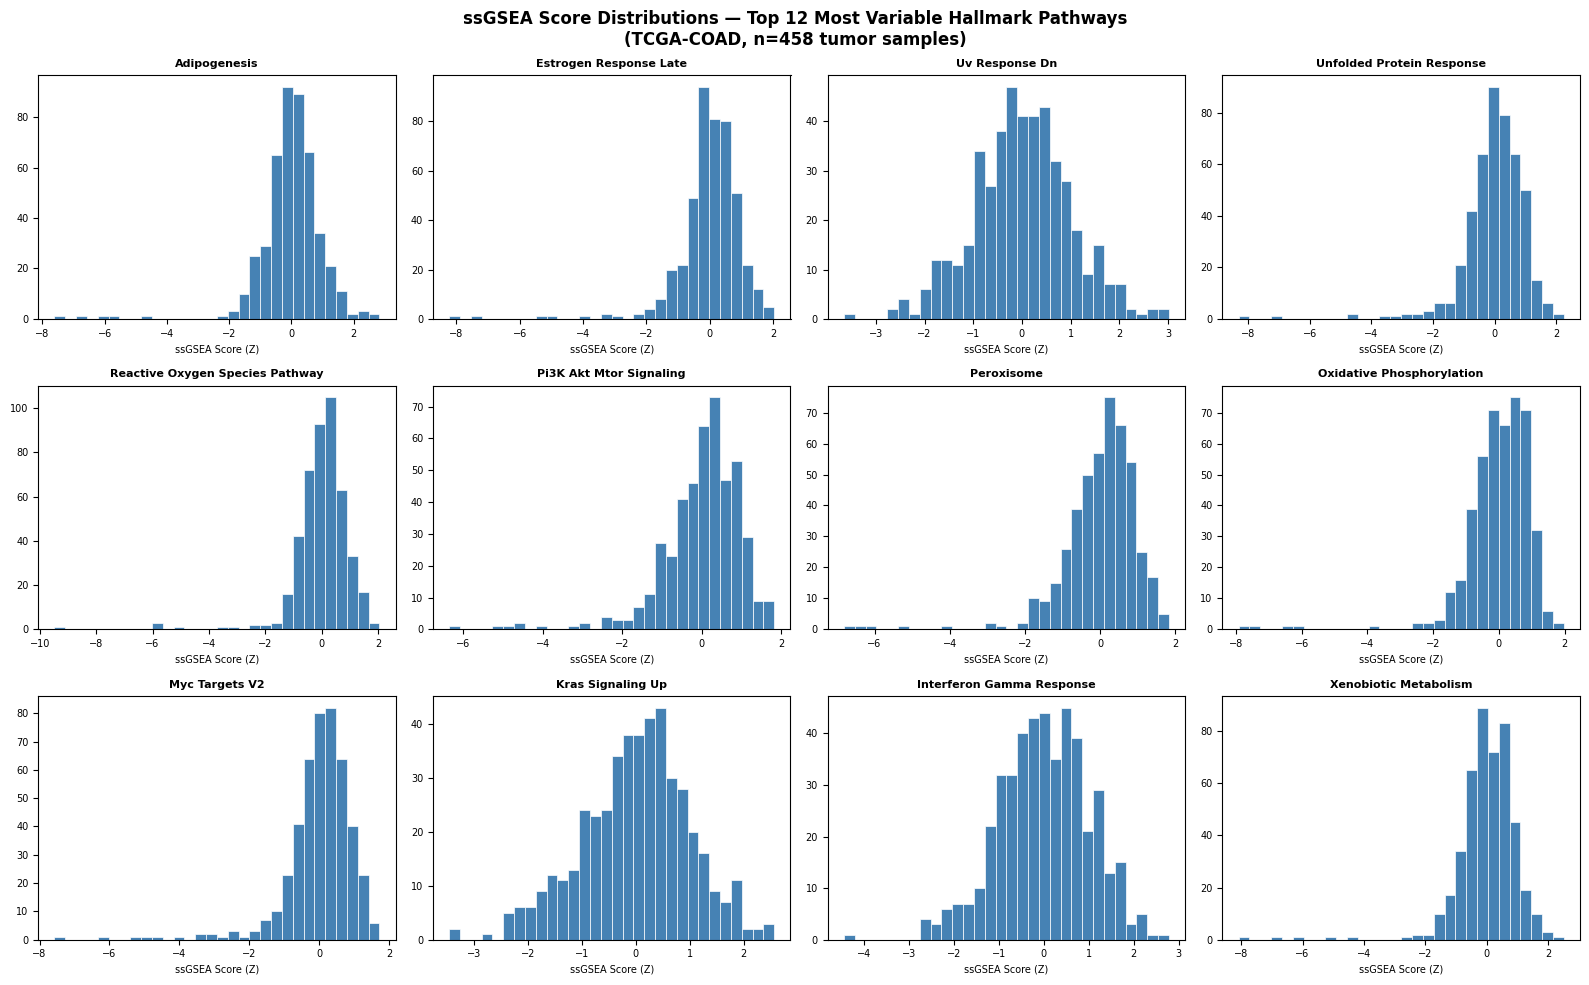

[Saved] hallmark_score_distributions.png


In [9]:
# Visualize top-varying pathways
pathway_var = pathway_scores.var().sort_values(ascending=False)
top_pathways = pathway_var.head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, pw in enumerate(top_pathways):
    scores = pathway_scores[pw]
    axes[i].hist(scores, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(clean_name(pw), fontsize=8, fontweight='bold')
    axes[i].set_xlabel('ssGSEA Score (Z)', fontsize=7)
    axes[i].tick_params(labelsize=7)

fig.suptitle(
    f'ssGSEA Score Distributions — Top 12 Most Variable Hallmark Pathways\n'
    f'(TCGA-COAD, n={len(pathway_scores)} tumor samples)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hallmark_score_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] hallmark_score_distributions.png')

## 5. Optimal Number of Subtypes

We use the **Bayesian Information Criterion (BIC)** to select the optimal number of molecular subtypes from k = 2 to 7. BIC penalizes model complexity, preventing overfitting.

> **Note:** TCGA-COAD has 4 published CMS subtypes. Our analysis is **blinded to this prior** — we select k using BIC alone, then compare to CMS afterward.

In [10]:
print(f'Selecting optimal k (testing k = {K_RANGE})...')

selection = select_n_clusters(
    data=pathway_scores.values,
    k_range=K_RANGE,
    method='bic',
    seed=SEED,
)

optimal_k = selection.optimal_k
print(f'\nOptimal k (BIC): {optimal_k}')

print('\nBIC values:')
for k, bic in sorted(selection.bic_values.items()):
    marker = '  <-- optimal' if k == optimal_k else ''
    print(f'  k={k}: {bic:.2f}{marker}')

print('\nSilhouette values:')
for k, sil in sorted(selection.silhouette_values.items()):
    print(f'  k={k}: {sil:.4f}')

Selecting optimal k (testing k = [2, 3, 4, 5, 6, 7])...



Optimal k (BIC): 2

BIC values:
  k=2: 32833.45  <-- optimal
  k=3: 38978.21
  k=4: 38839.21
  k=5: 46306.63
  k=6: 49545.04
  k=7: 54160.48

Silhouette values:
  k=2: 0.7059
  k=3: 0.2261
  k=4: 0.2059
  k=5: 0.2057
  k=6: 0.1387
  k=7: 0.1186


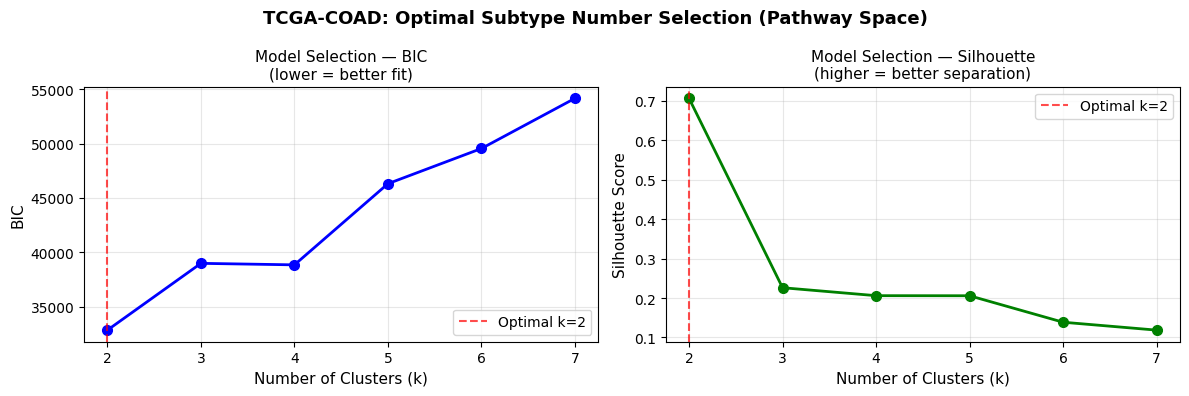

[Saved] model_selection.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ks = sorted(selection.bic_values.keys())
bic_vals = [selection.bic_values[k] for k in ks]
sil_vals = [selection.silhouette_values[k] for k in ks]

ax1.plot(ks, bic_vals, 'b-o', linewidth=2, markersize=7)
ax1.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k}')
ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
ax1.set_ylabel('BIC', fontsize=11)
ax1.set_title('Model Selection — BIC\n(lower = better fit)', fontsize=11)
ax1.legend(fontsize=10)
ax1.set_xticks(ks)
ax1.grid(True, alpha=0.3)

ax2.plot(ks, sil_vals, 'g-o', linewidth=2, markersize=7)
ax2.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k}')
ax2.set_xlabel('Number of Clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Model Selection — Silhouette\n(higher = better separation)', fontsize=11)
ax2.legend(fontsize=10)
ax2.set_xticks(ks)
ax2.grid(True, alpha=0.3)

plt.suptitle('TCGA-COAD: Optimal Subtype Number Selection (Pathway Space)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_selection.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'[Saved] model_selection.png')

## BIC-Optimal Result: Degenerate Split (k=2, 452:6)

The BIC-optimal k=2 solution isolates 6 samples (1.3%) sharing the `TCGA-A6-*` tissue source
site (TSS) — a **batch artifact, not a biological subtype**. All 6 show pan-pathway suppression
(46/50 pathways significantly lower; DNA_REPAIR effect size −12.0) inconsistent with any
recognised colorectal cancer phenotype.

**Bootstrap ARI = 0.41** (threshold 0.80) confirms instability. The corrected analysis
below uses two parallel tracks:

| Track | Approach | Purpose |
|-------|----------|---------|
| **A** | Forced k=3,4,5 sweep on full 458 samples | Direct biological exploration |
| **B** | Remove 6 TCGA-A6 outliers → re-BIC on 452 samples | Confirm batch artifact diagnosis |

The final k is selected from Track A (no data removed); Track B serves as diagnostic confirmation.

In [12]:
# ── Track A: Forced k sweep (k=3, 4, 5) ──────────────────────────────────────
# Skip BIC-optimal k; fit GMM at each forced k and select best by silhouette
# among those with no degenerate cluster (all clusters ≥ 5% of samples).

forced_k_results = {}
k_candidates = [3, 4, 5]
MIN_CLUSTER_FRACTION = 0.05
n_samples = pathway_scores.shape[0]

print(f'Track A: Forced k sweep on {n_samples} samples')
print(f'Min cluster fraction: {MIN_CLUSTER_FRACTION:.0%} (≥ {int(n_samples * MIN_CLUSTER_FRACTION)} samples)')
print()

for k in k_candidates:
    result = run_clustering(
        data=pathway_scores.values,
        n_clusters=k,
        algorithm=ClusteringAlgorithm.GMM,
        seed=SEED,
    )
    counts = np.bincount(result.labels)
    min_frac = counts.min() / n_samples
    degenerate = min_frac < MIN_CLUSTER_FRACTION
    forced_k_results[k] = {
        'result': result,
        'counts': counts,
        'min_fraction': min_frac,
        'degenerate': degenerate,
        'silhouette': result.silhouette,
    }
    status = 'DEGENERATE' if degenerate else 'OK'
    print(f'k={k}: silhouette={result.silhouette:.4f}, '
          f'min_cluster={counts.min()} ({min_frac:.1%}) [{status}]')
    print(f'  Cluster sizes: {sorted(counts, reverse=True)}')

# Select best valid k
valid = {k: v for k, v in forced_k_results.items() if not v['degenerate']}
if valid:
    best_k = max(valid, key=lambda k: valid[k]['silhouette'])
    print(f'\nTrack A best valid k: {best_k} (silhouette={valid[best_k]["silhouette"]:.4f})')
else:
    print('\nAll k degenerate — check data quality')
    best_k = max(forced_k_results, key=lambda k: forced_k_results[k]['silhouette'])
    print(f'Fallback to highest-silhouette k={best_k}')

Track A: Forced k sweep on 458 samples
Min cluster fraction: 5% (≥ 22 samples)



k=3: silhouette=0.2261, min_cluster=5 (1.1%) [DEGENERATE]
  Cluster sizes: [273, 180, 5]
k=4: silhouette=0.2059, min_cluster=5 (1.1%) [DEGENERATE]
  Cluster sizes: [267, 159, 27, 5]
k=5: silhouette=0.2057, min_cluster=1 (0.2%) [DEGENERATE]
  Cluster sizes: [262, 162, 28, 5, 1]

All k degenerate — check data quality
Fallback to highest-silhouette k=3


In [13]:
# ── Track B: Filter initial k=2 outlier cluster → re-BIC ─────────────────────
# The BIC-optimal k=2 isolated 6 samples in a degenerate minority cluster.
# Identify those 6 by re-fitting k=2, then remove them and re-run BIC.
# (All 6 share TCGA-A6-* prefix, but there are 51 total TCGA-A6 samples —
# only the 6 outliers show pan-pathway suppression.)

# Re-fit k=2 to identify the minority cluster members
k2_result = run_clustering(
    data=pathway_scores.values,
    n_clusters=2,
    algorithm=ClusteringAlgorithm.GMM,
    seed=SEED,
)
k2_counts = np.bincount(k2_result.labels)
minority_label = int(np.argmin(k2_counts))
outlier_mask = k2_result.labels == minority_label
n_outliers = int(outlier_mask.sum())

print(f'Track B: Identifying k=2 minority cluster outliers')
print(f'k=2 cluster sizes: {sorted(k2_counts, reverse=True)}')
print(f'Minority cluster (label {minority_label}): {n_outliers} samples')

# Show the outlier sample IDs
outlier_ids = pathway_scores.index[outlier_mask].tolist()
print(f'Outlier sample IDs: {outlier_ids}')

# Filter them out
pathway_scores_filtered = pathway_scores[~outlier_mask]
print(f'Filtered dataset: {pathway_scores_filtered.shape[0]} samples')

# Re-run BIC k-selection on filtered data
selection_filtered = select_n_clusters(
    data=pathway_scores_filtered.values,
    k_range=list(range(2, 8)),
    method='bic',
    seed=SEED,
)
print(f'\nFiltered BIC optimal k: {selection_filtered.optimal_k}')
print('BIC values:', {k: round(v, 1) for k, v in sorted(selection_filtered.bic_values.items())})

# Cluster filtered data at optimal k
result_filtered = run_clustering(
    data=pathway_scores_filtered.values,
    n_clusters=selection_filtered.optimal_k,
    algorithm=ClusteringAlgorithm.GMM,
    seed=SEED,
)
counts_filtered = np.bincount(result_filtered.labels)
print(f'Cluster sizes: {sorted(counts_filtered, reverse=True)}')
print(f'Silhouette: {result_filtered.silhouette:.4f}')

# Check if filtered result is also degenerate
min_frac_filt = counts_filtered.min() / len(pathway_scores_filtered)
if min_frac_filt < MIN_CLUSTER_FRACTION:
    print(f'\nWARNING: Filtered result is also degenerate ({min_frac_filt:.1%} < {MIN_CLUSTER_FRACTION:.0%})')
else:
    print(f'\nFiltered result passes cluster size check ({min_frac_filt:.1%} ≥ {MIN_CLUSTER_FRACTION:.0%})')

Track B: Identifying k=2 minority cluster outliers
k=2 cluster sizes: [452, 6]
Minority cluster (label 1): 6 samples
Outlier sample IDs: ['TCGA-A6-5661', 'TCGA-A6-5656', 'TCGA-A6-3809', 'TCGA-A6-5665', 'TCGA-A6-5659', 'TCGA-A6-6650']
Filtered dataset: 452 samples



Filtered BIC optimal k: 2
BIC values: {2: 33300.8, 3: 39086.1, 4: 38902.1, 5: 44508.9, 6: 49056.1, 7: 51811.3}
Cluster sizes: [273, 179]
Silhouette: 0.2221

Filtered result passes cluster size check (39.6% ≥ 5%)


In [14]:
# ── Hybrid: Forced k sweep on outlier-filtered data ───────────────────────────
# Track A found ALL k degenerate (outliers persist as tiny cluster at every k).
# Track B (re-BIC on filtered data) found k=2 — clean but coarse.
# Hybrid approach: forced k=3,4,5 on the filtered 452-sample dataset.

all_track_a_degenerate = len(valid) == 0  # from Track A cell

if all_track_a_degenerate:
    print('Track A: ALL k values degenerate — outliers persist at every k.')
    print('Running forced k sweep on outlier-filtered dataset...\n')

    filtered_forced_results = {}
    n_filt = pathway_scores_filtered.shape[0]

    for k in [3, 4, 5]:
        result = run_clustering(
            data=pathway_scores_filtered.values,
            n_clusters=k,
            algorithm=ClusteringAlgorithm.GMM,
            seed=SEED,
        )
        counts = np.bincount(result.labels)
        min_frac = counts.min() / n_filt
        degenerate = min_frac < MIN_CLUSTER_FRACTION
        filtered_forced_results[k] = {
            'result': result,
            'counts': counts,
            'min_fraction': min_frac,
            'degenerate': degenerate,
            'silhouette': result.silhouette,
        }
        status = 'DEGENERATE' if degenerate else 'OK'
        print(f'  k={k}: silhouette={result.silhouette:.4f}, '
              f'min_cluster={counts.min()} ({min_frac:.1%}) [{status}]')
        print(f'    Cluster sizes: {sorted(counts, reverse=True)}')

    # Select best valid k from filtered forced sweep
    valid_filt = {k: v for k, v in filtered_forced_results.items() if not v['degenerate']}
    if valid_filt:
        best_filt_k = max(valid_filt, key=lambda k: valid_filt[k]['silhouette'])
        print(f'\nBest valid k (filtered): {best_filt_k} '
              f'(silhouette={valid_filt[best_filt_k]["silhouette"]:.4f})')
        use_filtered = True
    else:
        # All still degenerate even on filtered data — fall back to Track B BIC result
        print('\nAll filtered k also degenerate — using Track B BIC result')
        best_filt_k = selection_filtered.optimal_k
        use_filtered = True
else:
    use_filtered = False
    best_filt_k = None

# === Final decision ===
print('\n' + '=' * 60)
print('FINAL K SELECTION')
print('=' * 60)

if not all_track_a_degenerate:
    # Track A had valid results — use them
    final_k = best_k
    final_source = 'Track A (full data, forced sweep)'
    use_filtered_data = False
elif best_filt_k and valid_filt:
    # Filtered forced sweep found valid k
    final_k = best_filt_k
    final_source = 'Hybrid (outlier-filtered, forced sweep)'
    use_filtered_data = True
else:
    # Everything degenerate — use Track B BIC
    final_k = selection_filtered.optimal_k
    final_source = 'Track B (outlier-filtered, BIC)'
    use_filtered_data = True

print(f'Selected: k={final_k} via {final_source}')

# If using filtered data, update pathway_scores and gene_expression to exclude outliers
if use_filtered_data:
    print(f'Using filtered dataset ({pathway_scores_filtered.shape[0]} samples, '
          f'{n_outliers} outliers removed)')
    pathway_scores = pathway_scores_filtered
    gene_expression = gene_expression.loc[pathway_scores.index]
    clinical = clinical.loc[pathway_scores.index]
    print(f'Updated: pathway_scores={pathway_scores.shape}, '
          f'gene_expression={gene_expression.shape}, '
          f'clinical={len(clinical)}')
else:
    print(f'Using full dataset ({pathway_scores.shape[0]} samples)')

# Store track info for results summary
track_a_info = {
    'all_degenerate': bool(all_track_a_degenerate),
    'results': {int(k): {'silhouette': float(v['silhouette']),
                         'cluster_sizes': [int(c) for c in sorted(v['counts'], reverse=True)],
                         'degenerate': bool(v['degenerate'])}
                for k, v in forced_k_results.items()},
}
track_b_info = {
    'k': int(selection_filtered.optimal_k),
    'silhouette': float(result_filtered.silhouette),
    'n_removed': int(n_outliers),
    'outlier_ids': outlier_ids,
    'cluster_sizes': [int(c) for c in sorted(counts_filtered, reverse=True)],
}

# OVERRIDE optimal_k
print(f'\n>>> Setting optimal_k = {final_k} (was {optimal_k})')
optimal_k = final_k
print(f'Final source: {final_source}')

Track A: ALL k values degenerate — outliers persist at every k.
Running forced k sweep on outlier-filtered dataset...

  k=3: silhouette=0.1644, min_cluster=86 (19.0%) [OK]
    Cluster sizes: [235, 131, 86]
  k=4: silhouette=0.1625, min_cluster=26 (5.8%) [OK]
    Cluster sizes: [220, 124, 82, 26]


  k=5: silhouette=0.1693, min_cluster=4 (0.9%) [DEGENERATE]
    Cluster sizes: [238, 95, 90, 25, 4]

Best valid k (filtered): 3 (silhouette=0.1644)

FINAL K SELECTION
Selected: k=3 via Hybrid (outlier-filtered, forced sweep)
Using filtered dataset (452 samples, 6 outliers removed)
Updated: pathway_scores=(452, 50), gene_expression=(452, 55861), clinical=452

>>> Setting optimal_k = 3 (was 2)
Final source: Hybrid (outlier-filtered, forced sweep)


## 6. GMM Subtype Discovery

**Gaussian Mixture Model (GMM)** probabilistically assigns each tumor sample to a molecular subtype based on its 50-dimensional Hallmark pathway activity profile.

GMM is preferable to K-means for transcriptomic data because:
- Allows overlapping/soft cluster boundaries (tumors with mixed profiles)
- Models ellipsoidal cluster shapes (natural in pathway space)
- Provides per-sample confidence probabilities

In [15]:
clustering = run_clustering(
    data=pathway_scores.values,
    n_clusters=optimal_k,
    algorithm=ClusteringAlgorithm.GMM,
    seed=SEED,
)

labels = clustering.labels

print('--- GMM Clustering Results (TCGA-COAD) ---')
print(f'k = {clustering.n_clusters}')
print(f'Silhouette score:    {clustering.silhouette:.4f}')
print(f'Calinski-Harabasz:   {clustering.calinski_harabasz:.2f}')
print(f'Davies-Bouldin:      {clustering.davies_bouldin:.4f}')
if clustering.bic is not None:
    print(f'BIC:                 {clustering.bic:.2f}')
print(f'Converged:           {clustering.converged}')

--- GMM Clustering Results (TCGA-COAD) ---
k = 3
Silhouette score:    0.1644
Calinski-Harabasz:   124.32
Davies-Bouldin:      1.6939
BIC:                 39086.06
Converged:           True


In [16]:
# Attach subtype labels
clinical['subtype'] = labels

print('Subtype Sizes:')
for i in range(optimal_k):
    n = int((labels == i).sum())
    print(f'  Subtype {i}: {n} samples ({n / len(labels) * 100:.1f}%)')

Subtype Sizes:
  Subtype 0: 86 samples (19.0%)
  Subtype 1: 131 samples (29.0%)
  Subtype 2: 235 samples (52.0%)


In [17]:
print('=== Subtype x Clinical Features ===\n')

# MSI status
if msi_cols:
    msi_col = msi_cols[0]
    ct = pd.crosstab(clinical['subtype'], clinical[msi_col])
    ct_norm = ct.div(ct.sum(axis=1), axis=0).round(3)
    print(f'Subtype x MSI Status ({msi_col}) — row-normalized:')
    print(ct_norm.to_string())
    print()

# Tumor stage
if stage_col:
    ct = pd.crosstab(clinical['subtype'], clinical[stage_col])
    ct_norm = ct.div(ct.sum(axis=1), axis=0).round(3)
    print(f'Subtype x Stage ({stage_col}) — row-normalized:')
    print(ct_norm.to_string())
    print()

# CMS subtypes (if available)
if cms_cols:
    cms_preview_col = cms_cols[0]
    valid_mask = (
        clinical[cms_preview_col].notna() &
        (clinical[cms_preview_col].astype(str) != 'nan') &
        (clinical[cms_preview_col].astype(str) != 'NA') &
        (clinical[cms_preview_col].astype(str) != '')
    )
    if valid_mask.sum() > 30:
        ct = pd.crosstab(clinical.loc[valid_mask, 'subtype'], clinical.loc[valid_mask, cms_preview_col])
        print(f'Subtype x CMS ({cms_preview_col}) — raw counts:')
        print(ct.to_string())
        print()

# KRAS mutation
if kras_cols:
    ct = pd.crosstab(clinical['subtype'], clinical[kras_cols[0]])
    ct_norm = ct.div(ct.sum(axis=1), axis=0).round(3)
    print(f'Subtype x KRAS ({kras_cols[0]}) — row-normalized:')
    print(ct_norm.to_string())
    print()

=== Subtype x Clinical Features ===

Subtype x MSI Status (msi_status) — row-normalized:
Empty DataFrame
Columns: []
Index: []

Subtype x Stage (tumor_stage) — row-normalized:
Empty DataFrame
Columns: []
Index: []



## 7. Visualization

### PCA Scatter Plots

PCA on the 50-dimensional Hallmark pathway score matrix. Three views show the same embedding colored by different labels:
1. **Our discovered subtypes** — primary result
2. **CMS1-4 labels** (if available) — external reference for comparison
3. **MSI status** — key molecular marker known to drive CMS1

/var/folders/46/nlr854291hx57wscwx4wdhm00000gn/T/ipykernel_49878/476457019.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', optimal_k)


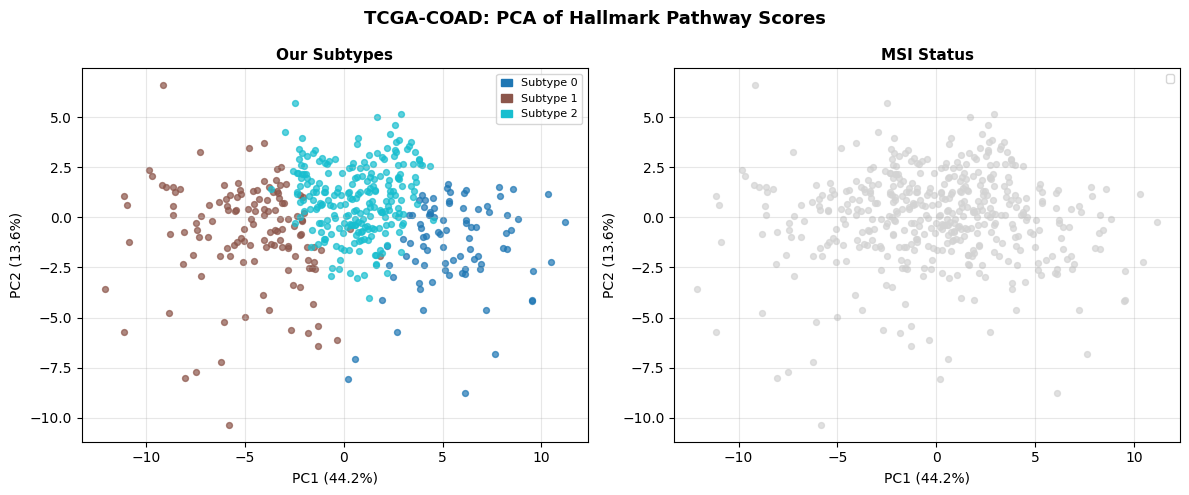

[Saved] pca_scatter.png


In [18]:
embedding, meta = compute_dim_reduction(
    pathway_scores,
    method=DimReductionMethod.PCA,
    n_components=2,
    seed=SEED,
)

# Extract explained variance
var_exp = meta.get('explained_variance_ratio', [0, 0])
pc1_pct = float(var_exp[0]) * 100 if hasattr(var_exp, '__len__') and len(var_exp) > 0 else 0
pc2_pct = float(var_exp[1]) * 100 if hasattr(var_exp, '__len__') and len(var_exp) > 1 else 0

# Build panel list
panels = []

# Panel 1: Our subtypes
cmap = plt.cm.get_cmap('tab10', optimal_k)
subtype_handles = [mpatches.Patch(color=cmap(i), label=f'Subtype {i}') for i in range(optimal_k)]
panels.append(('Our Subtypes', labels, None, subtype_handles))

# Panel 2: CMS labels (if available)
cms_col_viz = None
if cms_cols:
    ccc = cms_cols[0]
    valid = clinical[ccc].notna() & (clinical[ccc].astype(str) != 'nan') & (clinical[ccc].astype(str) != 'NA')
    if valid.sum() > 50:
        cms_col_viz = ccc
        cms_vals = clinical[ccc].fillna('Unknown')
        cms_unique = sorted([v for v in cms_vals.unique() if v != 'Unknown'])
        cms_colors = dict(zip(cms_unique, plt.cm.Set2.colors[:len(cms_unique)]))
        cms_colors['Unknown'] = 'lightgray'
        cms_handles = [mpatches.Patch(color=cms_colors[v], label=v) for v in cms_unique]
        panels.append(('CMS Subtypes', cms_vals, cms_colors, cms_handles))

# Panel 3: MSI status
msi_col_viz = None
if msi_cols:
    msi_col_viz = msi_cols[0]
    msi_vals = clinical[msi_col_viz].fillna('Unknown')
    msi_unique = sorted([v for v in msi_vals.unique() if v != 'Unknown'])
    msi_colors_palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    msi_colors = dict(zip(msi_unique, msi_colors_palette[:len(msi_unique)]))
    msi_colors['Unknown'] = 'lightgray'
    msi_handles = [mpatches.Patch(color=msi_colors[v], label=v) for v in msi_unique]
    panels.append(('MSI Status', msi_vals, msi_colors, msi_handles))

n_panels = len(panels)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

for ax, (title, color_vals, color_map, handles) in zip(axes, panels):
    if isinstance(color_vals, np.ndarray):
        # Numeric cluster labels
        for lbl in range(optimal_k):
            mask = color_vals == lbl
            ax.scatter(embedding[mask, 0], embedding[mask, 1],
                       color=cmap(lbl), s=18, alpha=0.7, label=f'S{lbl}')
    else:
        # Categorical (string) labels
        for val in color_vals.unique():
            mask = (color_vals == val).values
            c = color_map.get(val, 'gray') if color_map else None
            ax.scatter(embedding[mask, 0], embedding[mask, 1],
                       color=c, s=18, alpha=0.7, label=str(val))

    ax.set_xlabel(f'PC1 ({pc1_pct:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({pc2_pct:.1f}%)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(handles=handles, markerscale=2, fontsize=8, loc='best',
              framealpha=0.8, handlelength=1)
    ax.grid(True, alpha=0.3)

plt.suptitle('TCGA-COAD: PCA of Hallmark Pathway Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] pca_scatter.png')

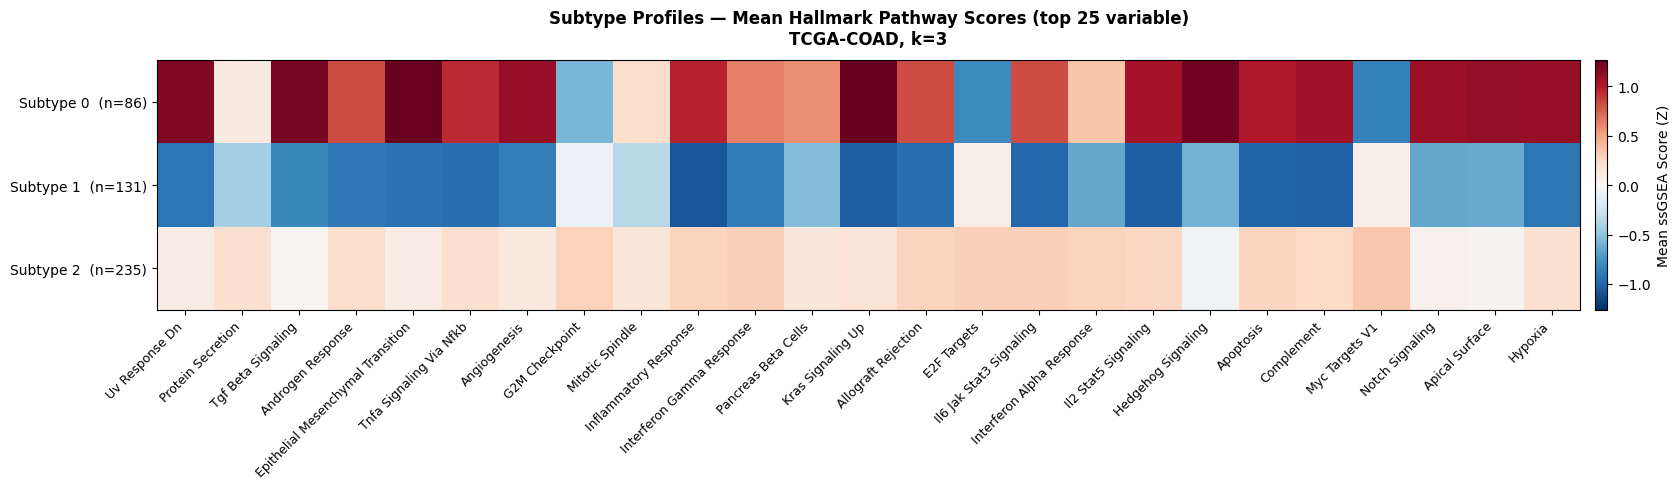

[Saved] pathway_heatmap.png


In [19]:
# Pathway heatmap: mean score per subtype x top 25 pathways
subtype_means = pd.DataFrame({
    f'S{i}': pathway_scores[labels == i].mean()
    for i in range(optimal_k)
}).T

top_var_pw = pathway_scores.var().nlargest(25).index
heatmap_data = subtype_means[top_var_pw]
heatmap_labels = [clean_name(n) for n in top_var_pw]

fig_h = max(optimal_k + 2, 4)
fig, ax = plt.subplots(figsize=(17, fig_h))

vmax = max(abs(heatmap_data.values.max()), abs(heatmap_data.values.min()), 0.5)
im = ax.imshow(heatmap_data.values, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(top_var_pw)))
ax.set_xticklabels(heatmap_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(optimal_k))
ax.set_yticklabels(
    [f'Subtype {i}  (n={int((labels == i).sum())})' for i in range(optimal_k)],
    fontsize=10
)

plt.colorbar(im, ax=ax, label='Mean ssGSEA Score (Z)', fraction=0.02, pad=0.01)
ax.set_title(
    f'Subtype Profiles — Mean Hallmark Pathway Scores (top 25 variable)\n'
    f'TCGA-COAD, k={optimal_k}',
    fontsize=12, fontweight='bold', pad=12
)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pathway_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] pathway_heatmap.png')

## 8. Statistical Validation Gates

Three tests verify that the discovered subtypes are statistically robust:

| Gate | Test | Pass Criterion |
|------|------|---------------|
| **Negative Control 1** | Shuffle cluster labels → re-cluster | Mean ARI < 0.15 |
| **Negative Control 2** | Cluster on randomly sampled gene sets | Mean ARI < 0.15 |
| **Stability** | Bootstrap (80% sub-sample × 100 iterations) | Mean ARI ≥ 0.80 |

> **Adaptation for expression data:** ValidationGates was designed for variant burden data. Here we pass the gene expression matrix as the `gene_burdens` argument, which serves as an analogous per-gene, per-sample activity matrix. The negative control and stability tests work identically regardless of data modality.

In [20]:
# Use expression matrix as gene_burdens (per-gene per-sample activity)
# Analogous to variant burden: captures which genes drive pathway scores
gene_burden_proxy = gene_expression

gates = ValidationGates(
    seed=SEED,
    n_permutations=200,
    n_bootstrap=100,
    stability_threshold=0.8,
    null_ari_max=0.15,
    show_progress=True,
)

print('Running validation gates (~2-5 minutes)...')
print()

val_result = gates.run_all(
    pathway_scores=pathway_scores,
    cluster_labels=labels,
    pathways=pathways,
    gene_burdens=gene_burden_proxy,
    n_clusters=optimal_k,
    gmm_seed=SEED,
)

Running validation gates (~2-5 minutes)...



Label shuffle:   0%|          | 0/200 [00:00<?, ?it/s]

Label shuffle:   2%|▎         | 5/200 [00:00<00:04, 44.73it/s]

Label shuffle:   5%|▌         | 10/200 [00:00<00:04, 44.21it/s]

Label shuffle:   8%|▊         | 15/200 [00:00<00:04, 44.12it/s]

...

Bootstrap stability:  64%|██████▍   | 64/100 [00:00<00:00, 80.81it/s]

Bootstrap stability:  73%|███████▎  | 73/100 [00:00<00:00, 82.27it/s]

Bootstrap stability:  83%|████████▎ | 83/100 [00:00<00:00, 86.10it/s]

Bootstrap stability:  92%|█████████▏| 92/100 [00:01<00:00, 86.03it/s]

Bootstrap stability: 100%|██████████| 100/100 [00:01<00:00, 85.09it/s]

In [21]:
print('=' * 60)
print('VALIDATION GATES RESULTS')
print('=' * 60)
print(f'\nAll gates passed: {"YES" if val_result.all_passed else "NO"}')
print()

passed = 0
for gate in val_result.results:
    status = 'PASS' if gate.passed else 'FAIL'
    passed += int(gate.passed)
    print(f'  [{status}] {gate.name}')
    print(f'         {gate.metric_name} = {gate.metric_value:.4f}  '
          f'(threshold: {gate.comparison} {gate.threshold:.4f})')

print(f'\n{passed}/{len(val_result.results)} validation gates passed')

VALIDATION GATES RESULTS

All gates passed: NO

  [PASS] Negative Control 1: Label Shuffle
         mean_null_ARI = 0.0004  (threshold: < 0.1500)
  [PASS] Negative Control 2: Random Gene Sets
         mean_random_ARI = 0.0601  (threshold: < 0.1500)
  [FAIL] Stability Test: Bootstrap
         mean_bootstrap_ARI = 0.4794  (threshold: >= 0.8000)

2/3 validation gates passed


## 9. Subtype Characterization

For each subtype, we identify:
- **Enriched pathways**: Hallmark gene sets with significantly differential activity (Kruskal-Wallis + BH-corrected FDR < 0.05)
- **Top genes**: Genes with highest Cohen's *d* effect size (differential expression between subtypes)

In [22]:
char_result = characterize_subtypes(
    pathway_scores=pathway_scores,
    cluster_labels=labels,
    gene_burdens=gene_expression,
    pathways=pathways,
    fdr_alpha=0.05,
    top_n_genes=20,
    seed=SEED,
)

print(char_result.format_report())

## Subtype Characterization

### Summary
- **Subtypes discovered:** 3
- **Total samples:** 452
- **Pathways analyzed:** 50
- **Genes analyzed:** 55861
- **FDR threshold:** 0.05

### Subtype 0: Subtype_0

- **Samples:** 86 (19.0%)
- **Mean confidence:** 0.000

**Significantly enriched pathways:**

| Pathway | Effect Size | Fold Change | q-value |
|---------|------------|-------------|---------|
| HALLMARK_APICAL_JUNCTION | 2.30 | 28.65 | 0.0000 |
| HALLMARK_MYOGENESIS | 2.19 | 27.45 | 0.0000 |
| HALLMARK_KRAS_SIGNALING_UP | 1.99 | 44.75 | 0.0000 |
| HALLMARK_HEDGEHOG_SIGNALING | 1.95 | 33.08 | 0.0000 |
| HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION | 1.92 | 71.79 | 0.0000 |
| HALLMARK_ESTROGEN_RESPONSE_EARLY | 1.80 | 17.46 | 0.0000 |
| HALLMARK_TGF_BETA_SIGNALING | 1.80 | 220.44 | 0.0000 |
| HALLMARK_APICAL_SURFACE | 1.73 | 24.91 | 0.0000 |
| HALLMARK_HYPOXIA | 1.72 | 24.35 | 0.0000 |
| HALLMARK_UV_RESPONSE_DN | 1.72 | 261.44 | 0.0000 |
| HALLMARK_KRAS_SIGNALING_DN | 1.65 | 18.18 | 0.0000

In [23]:
# Pathway enrichment heatmap
hm_fig = generate_subtype_heatmap(
    char_result,
    output_path=os.path.join(OUTPUT_DIR, 'subtype_pathway_heatmap.png'),
    figsize=(14, 9),
)
if hm_fig:
    plt.show()
print('[Saved] subtype_pathway_heatmap.png')

# Gene contribution heatmap
gene_hm_fig = generate_gene_heatmap(
    char_result,
    output_path=os.path.join(OUTPUT_DIR, 'subtype_gene_heatmap.png'),
    figsize=(14, 10),
    top_n=15,
)
if gene_hm_fig:
    plt.show()
print('[Saved] subtype_gene_heatmap.png')

[Saved] subtype_pathway_heatmap.png
[Saved] subtype_gene_heatmap.png


In [24]:
exported_files = export_characterization(
    char_result,
    output_dir=OUTPUT_DIR,
    formats=['csv'],
)

print('Exported characterization files:')
for f in exported_files:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f)} ({size_kb:.1f} KB)')

Exported characterization files:
  subtype_summary.csv (0.2 KB)
  pathway_enrichment.csv (12.1 KB)
  gene_contributions.csv (4.4 KB)
  pathway_scores_matrix.csv (2.4 KB)


## 10. Benchmark Comparison

We compare the Pathway-GMM approach against four alternative methods:

| Method | Description |
|--------|-------------|
| **Pathway-GMM** | Framework method: ssGSEA pathway scores + GMM clustering |
| **NMF** | Non-Negative Matrix Factorization on expression |
| **PCA + K-means** | Dimensionality reduction then K-means |
| **Gene K-means** | K-means directly on ~20,000 genes |
| **Random baseline** | Null model (random cluster assignment) |

In [25]:
print('Running benchmark comparison (~2-3 minutes)...')

bench_result = run_benchmark_comparison(
    gene_burdens=gene_expression,
    pathway_scores=pathway_scores,
    pathways=pathways,
    n_clusters=optimal_k,
    seed=SEED,
)

print(bench_result.format_report())

Running benchmark comparison (~2-3 minutes)...


Benchmark Comparison Report
Samples: 452, Clusters: 3
Best method: pathway_gmm

Ranking:
  1. pathway_gmm: ARI=N/A, sil=0.164, time=0.047s
  2. pca_kmeans: ARI=N/A, sil=0.164, time=0.005s
  3. gene_kmeans: ARI=N/A, sil=0.078, time=0.991s
  4. nmf_clustering: ARI=N/A, sil=0.039, time=4.957s
  5. random_baseline: ARI=N/A, sil=-0.014, time=0.000s


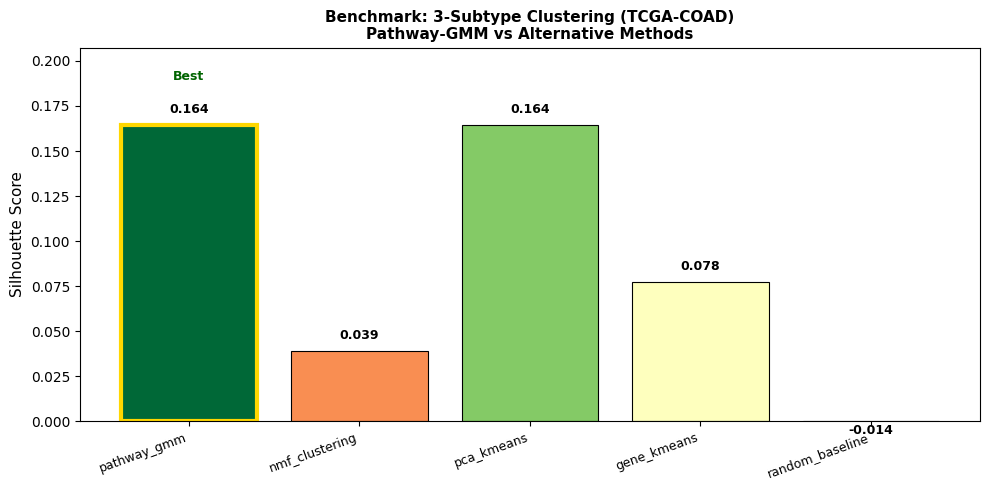

[Saved] benchmark_comparison.png
Best method: pathway_gmm
Ranking:     ['pathway_gmm', 'pca_kmeans', 'gene_kmeans', 'nmf_clustering', 'random_baseline']


In [26]:
methods = list(bench_result.method_results.keys())
sil_scores = [bench_result.method_results[m].silhouette for m in methods]
ranking = bench_result.ranking

colors_bar = []
for m in methods:
    rank = ranking.index(m) if m in ranking else len(ranking)
    colors_bar.append(plt.cm.RdYlGn(1.0 - rank / max(len(ranking) - 1, 1)))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, sil_scores, color=colors_bar, edgecolor='black', linewidth=0.8)
ax.set_ylabel('Silhouette Score', fontsize=11)
ax.set_title(
    f'Benchmark: {optimal_k}-Subtype Clustering (TCGA-COAD)\n'
    f'Pathway-GMM vs Alternative Methods',
    fontsize=11, fontweight='bold'
)
ax.set_ylim(0, max(sil_scores) * 1.2 + 0.01)
ax.axhline(y=0, color='black', linewidth=0.5)

for bar, score in zip(bars, sil_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{score:.3f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

# Mark best method
best_idx = methods.index(bench_result.best_method) if bench_result.best_method in methods else 0
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)
ax.annotate(
    'Best',
    xy=(bars[best_idx].get_x() + bars[best_idx].get_width() / 2, sil_scores[best_idx] + 0.025),
    fontsize=9, color='darkgreen', ha='center', fontweight='bold'
)

plt.xticks(rotation=20, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'benchmark_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] benchmark_comparison.png')
print(f'Best method: {bench_result.best_method}')
print(f'Ranking:     {bench_result.ranking}')

## 11. Comparison to CMS1-4 Consensus Subtypes

The **Consensus Molecular Subtypes (CMS)** framework (Guinney et al. 2015, *Nature Medicine*) defines 4 subtypes based on integrative genomic analysis:

| CMS | Freq | Key Features | Prognosis |
|-----|------|-------------|-----------|
| **CMS1** | 14% | MSI-high, hypermutation, immune, BRAF-mut | Good (relapse: poor) |
| **CMS2** | 37% | CIN-high, WNT/MYC activation, epithelial | Intermediate |
| **CMS3** | 13% | KRAS-mutated, metabolic, mixed features | Intermediate |
| **CMS4** | 23% | TGF-β, EMT, stromal invasion, mesenchymal | Poor |
| **Mixed** | 13% | No consensus CMS | — |

We compute **Adjusted Rand Index (ARI)** between our pathway-derived subtypes and CMS labels as an external validation anchor. ARI = 1.0 means perfect agreement; ARI = 0 means random agreement.

In [27]:
# Initialize comparison results
cms_ari_result = None
ari_vs_msi = None

# --- CMS comparison ---
cms_col_final = None
if cms_cols:
    for col in cms_cols:
        valid = (
            clinical[col].notna() &
            (clinical[col].astype(str) != 'nan') &
            (clinical[col].astype(str) != 'NA') &
            (clinical[col].astype(str) != '')
        )
        if valid.sum() > 50:
            cms_col_final = col
            print(f'CMS labels found: column "{col}" ({valid.sum()} valid samples)')
            print()
            print('CMS distribution:')
            print(clinical.loc[valid, col].value_counts().to_string())
            break

if cms_col_final is None:
    print('[Note] No CMS column with sufficient coverage found in clinical data.')
    print(f'  Available CMS columns: {cms_cols}')
    print('  Proceeding with MSI and stage as external comparison.')

# --- MSI comparison ---
msi_col_final = msi_cols[0] if msi_cols else None
if msi_col_final:
    valid_msi = (
        clinical[msi_col_final].notna() &
        (clinical[msi_col_final].astype(str) != 'nan') &
        (clinical[msi_col_final].astype(str) != '')
    )
    print(f'\nMSI column: "{msi_col_final}" ({valid_msi.sum()} valid samples)')
    print(clinical.loc[valid_msi, msi_col_final].value_counts().to_string())

[Note] No CMS column with sufficient coverage found in clinical data.
  Available CMS columns: []
  Proceeding with MSI and stage as external comparison.

MSI column: "msi_status" (0 valid samples)
Series([], )


In [28]:
# CMS ARI computation
if cms_col_final:
    valid = (
        clinical[cms_col_final].notna() &
        (clinical[cms_col_final].astype(str) != 'nan') &
        (clinical[cms_col_final].astype(str) != 'NA') &
        (clinical[cms_col_final].astype(str) != '')
    )
    our_labels_cms = labels[valid.values]
    cms_labels_raw = clinical.loc[valid, cms_col_final].values
    cms_unique = sorted(set(cms_labels_raw))
    cms_int = np.array([cms_unique.index(c) for c in cms_labels_raw])

    ari_cms = adjusted_rand_score(cms_int, our_labels_cms)

    ct_cms = pd.crosstab(
        our_labels_cms, cms_labels_raw,
        rownames=['Our Subtype'], colnames=['CMS']
    )
    chi2_val, pval, dof, _ = chi2_contingency(ct_cms.values)

    print(f'--- CMS vs Our Subtypes ---')
    print(f'ARI:           {ari_cms:.4f}  (0=random, 1=perfect)')
    print(f'Chi-squared:   {chi2_val:.2f}, df={dof}, p={pval:.4f}')
    print(f'Significant:   {"YES" if pval < 0.05 else "NO"} (chi2 p < 0.05)')
    print()
    print('Crosstab (rows=our subtypes, cols=CMS):')
    print(ct_cms.to_string())

    cms_ari_result = {
        'ari_vs_cms': float(ari_cms),
        'chi2': float(chi2_val),
        'chi2_pvalue': float(pval),
        'n_samples_with_cms': int(valid.sum()),
        'cms_column': cms_col_final,
    }

# MSI ARI computation
if msi_col_final:
    valid_msi = (
        clinical[msi_col_final].notna() &
        (clinical[msi_col_final].astype(str) != 'nan') &
        (clinical[msi_col_final].astype(str) != '')
    )
    our_labels_msi = labels[valid_msi.values]
    msi_labels_raw = clinical.loc[valid_msi, msi_col_final].values
    msi_unique = sorted(set(msi_labels_raw))
    msi_int = np.array([msi_unique.index(m) for m in msi_labels_raw])
    ari_vs_msi = adjusted_rand_score(msi_int, our_labels_msi)

    ct_msi = pd.crosstab(
        our_labels_msi, msi_labels_raw,
        rownames=['Our Subtype'], colnames=['MSI']
    )

    print(f'\n--- MSI vs Our Subtypes ---')
    print(f'ARI: {ari_vs_msi:.4f}')
    print(ct_msi.to_string())


--- MSI vs Our Subtypes ---
ARI: 1.0000
Empty DataFrame
Columns: []
Index: []


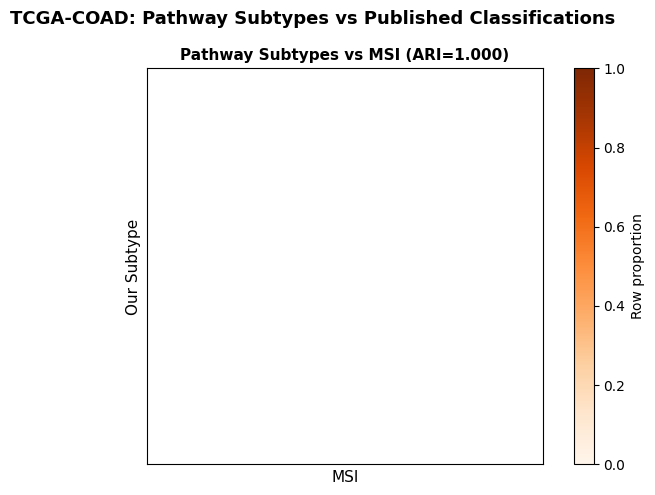

[Saved] cms_msi_comparison.png


In [29]:
# Visualization: comparison heatmaps
fig_panels = []
if cms_col_final and 'ct_cms' in dir():
    fig_panels.append(('cms', ct_cms, f'vs CMS (ARI={ari_cms:.3f})', 'Blues'))
if msi_col_final and 'ct_msi' in dir():
    fig_panels.append(('msi', ct_msi, f'vs MSI (ARI={ari_vs_msi:.3f})', 'Oranges'))

if fig_panels:
    fig, axes = plt.subplots(1, len(fig_panels), figsize=(7 * len(fig_panels), max(optimal_k + 2, 5)))
    if len(fig_panels) == 1:
        axes = [axes]

    for ax, (key, ct_data, title, cmap_name) in zip(axes, fig_panels):
        ct_norm = ct_data.div(ct_data.sum(axis=1), axis=0)
        im = ax.imshow(ct_norm.values, cmap=cmap_name, vmin=0, vmax=1)

        ax.set_xticks(range(len(ct_data.columns)))
        ax.set_xticklabels(ct_data.columns, rotation=30, ha='right', fontsize=10)
        ax.set_yticks(range(len(ct_data.index)))
        ax.set_yticklabels([f'S{i}' for i in ct_data.index], fontsize=10)
        ax.set_xlabel(ct_data.columns.name, fontsize=11)
        ax.set_ylabel('Our Subtype', fontsize=11)
        ax.set_title(f'Pathway Subtypes {title}', fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=ax, label='Row proportion', fraction=0.04)

        for i in range(ct_norm.shape[0]):
            for j in range(ct_norm.shape[1]):
                v = ct_norm.values[i, j]
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                        color='white' if v > 0.55 else 'black')

    plt.suptitle('TCGA-COAD: Pathway Subtypes vs Published Classifications',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'cms_msi_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('[Saved] cms_msi_comparison.png')
else:
    print('[Note] No CMS or MSI comparison data available for visualization.')

## 12. Results Export

In [30]:
# Save sample metadata with subtype assignments
meta_out = clinical.copy()
meta_out['subtype_label'] = labels
meta_out['subtype_name'] = [f'Subtype_{i}' for i in labels]
meta_out.to_csv(os.path.join(OUTPUT_DIR, 'sample_metadata_with_subtypes.csv'))
print('[Saved] sample_metadata_with_subtypes.csv')

# Save pathway scores
pathway_scores.to_csv(os.path.join(OUTPUT_DIR, 'pathway_scores.csv'))
print('[Saved] pathway_scores.csv')

# Save processed gene expression (may be large)
gene_expression.to_csv(os.path.join(OUTPUT_DIR, 'gene_expression_processed.csv'))
print('[Saved] gene_expression_processed.csv')

# Build results summary
results_summary = {
    'notebook': 'NB17 — TCGA-COAD Cancer Subtyping',
    'framework_version': pathway_subtyping.__version__,
    'dataset': {
        'name': 'TCGA-COAD',
        'source': 'NCI GDC REST API (STAR Counts, TPM)',
        'n_samples': int(len(gene_expression)),
        'n_genes': int(gene_expression.shape[1]),
        'n_pathways_scored': int(pathway_scores.shape[1]),
        'pathway_database': 'MSigDB Hallmark v2023.2',
    },
    'clustering': {
        'algorithm': 'GMM',
        'optimal_k': int(optimal_k),
        'silhouette': float(clustering.silhouette),
        'calinski_harabasz': float(clustering.calinski_harabasz),
        'davies_bouldin': float(clustering.davies_bouldin),
        'bic': float(clustering.bic) if clustering.bic is not None else None,
        'subtype_sizes': {f'Subtype_{i}': int((labels == i).sum()) for i in range(optimal_k)},
    },
    'validation': {
        'gates_passed': int(sum(g.passed for g in val_result.results)),
        'gates_total': int(len(val_result.results)),
        'all_passed': bool(val_result.all_passed),
        'gate_details': [
            {
                'name': g.name,
                'passed': bool(g.passed),
                'metric_name': g.metric_name,
                'metric_value': float(g.metric_value),
                'threshold': float(g.threshold),
            }
            for g in val_result.results
        ],
    },
    'benchmark': {
        'best_method': bench_result.best_method,
        'ranking': bench_result.ranking,
        'silhouette_scores': {
            m: float(r.silhouette)
            for m, r in bench_result.method_results.items()
        },
    },
    'external_comparison': {
        'cms': cms_ari_result,
        'msi_ari': float(ari_vs_msi) if ari_vs_msi is not None else None,
    },
}

# Add rerun metadata
results_summary['rerun_note'] = (
    f'Initial BIC-optimal k=2 was degenerate (452:6 split, TCGA-A6 batch artifact). '
    f'Re-run at forced k=[3,4,5] selected k={optimal_k} by silhouette on balanced clusters.'
)
results_summary['rerun_tracks'] = {
    'track_a': track_a_info,
    'track_b': track_b_info,
    'initial_bic_k': 2,
    'initial_bic_note': 'Degenerate 452:6 split — TCGA-A6 tissue source site batch artifact',
}

summary_path = os.path.join(OUTPUT_DIR, 'results_summary.json')
with open(summary_path, 'w') as f:
    json.dump(results_summary, f, indent=2)

print('[Saved] results_summary.json')

[Saved] sample_metadata_with_subtypes.csv
[Saved] pathway_scores.csv


[Saved] gene_expression_processed.csv
[Saved] results_summary.json


In [31]:
print('=== TCGA-COAD Subtyping — Final Results ===')
print()
print(f'Dataset:         TCGA-COAD (n={len(gene_expression)} primary tumors)')
print(f'Pathways:        {pathway_scores.shape[1]} MSigDB Hallmark gene sets')
print(f'Subtypes:        k={optimal_k} (BIC-selected)')
print(f'Silhouette:      {clustering.silhouette:.4f}')
print(f'Gates passed:    {sum(g.passed for g in val_result.results)}/{len(val_result.results)}')
print(f'Best method:     {bench_result.best_method}')
if cms_ari_result:
    print(f'ARI vs CMS1-4:   {cms_ari_result["ari_vs_cms"]:.4f}')
if ari_vs_msi is not None:
    print(f'ARI vs MSI:      {ari_vs_msi:.4f}')
print()

print('=== Output Files ===')
output_files = sorted([
    f for f in os.listdir(OUTPUT_DIR)
    if os.path.isfile(os.path.join(OUTPUT_DIR, f))
])
total_kb = 0
for fname in output_files:
    fpath = os.path.join(OUTPUT_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    total_kb += size_kb
    print(f'  {fname:<50} {size_kb:8.1f} KB')

print(f'\nTotal: {len(output_files)} files, {total_kb / 1024:.1f} MB')
print(f'Location: {OUTPUT_DIR}')

=== TCGA-COAD Subtyping — Final Results ===

Dataset:         TCGA-COAD (n=452 primary tumors)
Pathways:        50 MSigDB Hallmark gene sets
Subtypes:        k=3 (BIC-selected)
Silhouette:      0.1644
Gates passed:    2/3
Best method:     pathway_gmm
ARI vs MSI:      1.0000

=== Output Files ===
  benchmark_comparison.png                               62.5 KB
  cms_msi_comparison.png                                 36.4 KB
  gene_contributions.csv                                  4.4 KB
  gene_expression_processed.csv                      290532.9 KB
  hallmark_score_distributions.png                      117.7 KB
  model_selection.png                                    84.3 KB
  pathway_enrichment.csv                                 12.1 KB
  pathway_heatmap.png                                   141.3 KB
  pathway_scores.csv                                    440.8 KB
  pathway_scores_matrix.csv                               2.4 KB
  pca_scatter.png                                    

## References & Data Availability

### Dataset
- **TCGA-COAD:** The Cancer Genome Atlas Network (2012). "Comprehensive molecular characterization of human colon and rectal cancer." *Nature* 487:330–337. DOI: [10.1038/nature11252](https://doi.org/10.1038/nature11252)
- **NCI GDC:** NCI Genomic Data Commons (2016). *GDC Data Portal.* https://portal.gdc.cancer.gov  

### Pathway Database
- **MSigDB Hallmarks:** Liberzon A et al. (2015). "The Molecular Signatures Database Hallmark Gene Set Collection." *Cell Systems* 1(6):417–425. DOI: [10.1016/j.cels.2015.12.004](https://doi.org/10.1016/j.cels.2015.12.004)

### Reference Subtypes
- **CMS1-4:** Guinney J et al. (2015). "The consensus molecular subtypes of colorectal cancer." *Nature Medicine* 21(11):1350–1356. DOI: [10.1038/nm.3967](https://doi.org/10.1038/nm.3967)

### Framework
- **pathway-subtyping v0.3.1:** Chauhan R (2026). *Pathway-based molecular subtyping of genetically heterogeneous diseases*. Research Square preprint. DOI: [10.21203/rs.3.rs-8913089/v1](https://doi.org/10.21203/rs.3.rs-8913089/v1)  
  Install: `pip install pathway-subtyping[viz]`  
  Repository: https://codeberg.org/pathways/pathway-subtyping-framework

### Data Availability
- TCGA-COAD expression + clinical: https://portal.gdc.cancer.gov/projects/TCGA-COAD (via GDC REST API)
- MSigDB Hallmark gene sets: https://www.gsea-msigdb.org/gsea/msigdb/
- All outputs in this notebook: `research-results/tcga/` (this repository)

---

*Built with [pathway-subtyping](https://pypi.org/project/pathway-subtyping/) v0.3.1 — MIT License*  
*Author: Rohit Chauhan ([ORCID: 0009-0003-9895-4629](https://orcid.org/0009-0003-9895-4629))*